In [1]:
# Для начала подключим требуемые библиотеки
import pandas as pd
import requests
import os
from urllib.parse import urlencode
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from operator import attrgetter

## Загрузка данных

In [2]:
# Скачаем необходимые файлы с Yandex диска

# Список публичных ссылок на файлы
public_keys = {
    'kicksharing.csv': 'https://disk.yandex.ru/d/AstnTazo4VFH7A'
}

base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'

# Создаем цикл для обработки каждого файла в словаре
for filename, public_key in public_keys.items():
    print(f"Начинаем скачивание файла: {filename}...")

    # Получаем загрузочную ссылку для текущего файла
    final_url = base_url + urlencode(dict(public_key=public_key))
    response = requests.get(final_url)
    download_url = response.json()['href']

    # Загружаем файл и сохраняем его с нужным именем
    download_response = requests.get(download_url)
    
    with open(filename, 'wb') as f:
        f.write(download_response.content)

    print(f"Файл '{filename}' успешно скачан!")

print("\nЗагрузка всех файлов завершена.")

Начинаем скачивание файла: kicksharing.csv...
Файл 'kicksharing.csv' успешно скачан!

Загрузка всех файлов завершена.


In [3]:
df = pd.read_csv('kicksharing.csv')

Посмотрим на данные. А также проверим, что все считалось верно

In [4]:
df.head()

,order_rk,party_rk,gender_cd,age,education_level_cd,marital_status_cd,lvn_state_nm,minute_cost,activation_cost,hold_amount,transport_model,distance_km,created_dttm,book_start_dttm,book_end_dttm,book_time_zone_cd,local_book_start_dttm,nominal_price_rub_amt,loyalty_accrual_rub_amt,loyalty_accrual_bns_amt
0,266071307,761067705,M,40,UGR,DIV,ТЮМЕНСКАЯ ОБЛ,4.99,30.0,300.0,SL,3.690479,2024-08-07 09:47:25.000000,2024-08-07 09:47:29.325252,2024-08-07 10:07:59.339524,5,2024-08-07 11:47:29.325252,134.79,19.48,NaN
1,355113920,614049469,F,30,GRD,MAR,РОСТОВСКАЯ ОБЛ,8.49,50.0,300.0,SL,1.114912,2024-10-17 14:57:20.000000,2024-10-17 14:57:24.586000,2024-10-17 15:04:19.419607,3,2024-10-17 14:57:24.586000,109.43,40.30,NaN
2,347424551,757583701,M,28,UGR,UNM,СВЕРДЛОВСКАЯ ОБЛ,5.99,30.0,300.0,E,1.515612,2024-09-19 05:31:41.000000,2024-09-19 05:34:59.476000,2024-09-19 05:41:50.164372,5,2024-09-19 07:34:59.476000,71.93,10.79,NaN
3,351562959,541367366,M,24,GRD,UNM,Г МОСКВА,8.99,50.0,300.0,SL,0.499411,2024-10-04 16:05:09.000000,2024-10-04 16:05:13.162000,2024-10-04 16:07:31.724918,3,2024-10-04 16:05:13.162000,76.97,7.70,NaN
4,258647149,238473615,M,34,NaN,NaN,Г МОСКВА,6.99,50.0,300.0,SL,2.602028,2024-07-10 06:57:40.000000,2024-07-10 06:57:43.017125,2024-07-10 07:07:48.446462,3,2024-07-10 06:57:43.017125,126.89,25.38,NaN


In [5]:
df.shape

(396749, 20)

In [6]:
# Проверим все ли данные в нужном типе
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396749 entries, 0 to 396748
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_rk                 396749 non-null  int64  
 1   party_rk                 396749 non-null  int64  
 2   gender_cd                393828 non-null  object 
 3   age                      396749 non-null  int64  
 4   education_level_cd       190059 non-null  object 
 5   marital_status_cd        217729 non-null  object 
 6   lvn_state_nm             362572 non-null  object 
 7   minute_cost              396749 non-null  float64
 8   activation_cost          396749 non-null  float64
 9   hold_amount              396749 non-null  float64
 10  transport_model          396749 non-null  object 
 11  distance_km              396749 non-null  float64
 12  created_dttm             396749 non-null  object 
 13  book_start_dttm          396749 non-null  object 
 14  book

## Обработка и подготовка данных

In [7]:
# Почти все данные в нужном типе, кроме дат. Переведем их в нужный формат:

df['created_dttm'] = pd.to_datetime(df['created_dttm'])
df['book_start_dttm'] = pd.to_datetime(df['book_start_dttm'])
df['book_end_dttm'] = pd.to_datetime(df['book_end_dttm']) 
df['local_book_start_dttm'] = pd.to_datetime(df['local_book_start_dttm']) 

In [8]:
# Проверим количество пустых значений в процентном соотношении
round((df.isnull().sum()/df.shape[0]) * 100, 2)

order_rk                    0.00
party_rk                    0.00
gender_cd                   0.74
age                         0.00
education_level_cd         52.10
marital_status_cd          45.12
lvn_state_nm                8.61
minute_cost                 0.00
activation_cost             0.00
hold_amount                 0.00
transport_model             0.00
distance_km                 0.00
created_dttm                0.00
book_start_dttm             0.00
book_end_dttm               0.00
book_time_zone_cd           0.00
local_book_start_dttm       0.00
nominal_price_rub_amt       0.00
loyalty_accrual_rub_amt     7.50
loyalty_accrual_bns_amt    94.47
dtype: float64

### Отсюда мы можем сделать уже некоторые выводы:

1. Практически в 50% случаев мы не знаем уровень образования или семейный статус. В случае анализа этих данных необходимо убрать пустые значения и работать с новым очищенным набором данных
2. Большая часть клиентов (около 92,5 %) оплачивают поездки через дебетовые карты или кредитные карты других банков. Только 5,5 % клиентов оплачивают поездки с кредитной карты Т-банка.

In [9]:
df.head()

,order_rk,party_rk,gender_cd,age,education_level_cd,marital_status_cd,lvn_state_nm,minute_cost,activation_cost,hold_amount,transport_model,distance_km,created_dttm,book_start_dttm,book_end_dttm,book_time_zone_cd,local_book_start_dttm,nominal_price_rub_amt,loyalty_accrual_rub_amt,loyalty_accrual_bns_amt
0,266071307,761067705,M,40,UGR,DIV,ТЮМЕНСКАЯ ОБЛ,4.99,30.0,300.0,SL,3.690479,2024-08-07 09:47:25,2024-08-07 09:47:29.325252,2024-08-07 10:07:59.339524,5,2024-08-07 11:47:29.325252,134.79,19.48,NaN
1,355113920,614049469,F,30,GRD,MAR,РОСТОВСКАЯ ОБЛ,8.49,50.0,300.0,SL,1.114912,2024-10-17 14:57:20,2024-10-17 14:57:24.586000,2024-10-17 15:04:19.419607,3,2024-10-17 14:57:24.586000,109.43,40.30,NaN
2,347424551,757583701,M,28,UGR,UNM,СВЕРДЛОВСКАЯ ОБЛ,5.99,30.0,300.0,E,1.515612,2024-09-19 05:31:41,2024-09-19 05:34:59.476000,2024-09-19 05:41:50.164372,5,2024-09-19 07:34:59.476000,71.93,10.79,NaN
3,351562959,541367366,M,24,GRD,UNM,Г МОСКВА,8.99,50.0,300.0,SL,0.499411,2024-10-04 16:05:09,2024-10-04 16:05:13.162000,2024-10-04 16:07:31.724918,3,2024-10-04 16:05:13.162000,76.97,7.70,NaN
4,258647149,238473615,M,34,NaN,NaN,Г МОСКВА,6.99,50.0,300.0,SL,2.602028,2024-07-10 06:57:40,2024-07-10 06:57:43.017125,2024-07-10 07:07:48.446462,3,2024-07-10 06:57:43.017125,126.89,25.38,NaN


### Проверим есть ли в идентификаторе заказов (поездок) дубликаты:

In [10]:
duplicates = df[df.order_rk.duplicated(keep=False)]
duplicates.shape[0]

0

### Проверим есть ли аномалии в данных:

In [11]:
df[['age', 'distance_km']].describe()

,age,distance_km
count,396749.000000,396749.000000
mean,31.544006,3.681031
std,9.434545,141.862349
min,12.000000,0.000000
25%,24.000000,0.941054
50%,31.000000,1.729883
75%,37.000000,3.063694
max,94.000000,56012.640308


Можно заметить аномалию в максимальном кол-ве километров. Среднее значение равно 3,68 а медиана 1,72 - из этого следует что у нас есть выбросы. Посмотрим так ли это при помощи боксплота:

<Axes: ylabel='distance_km'>

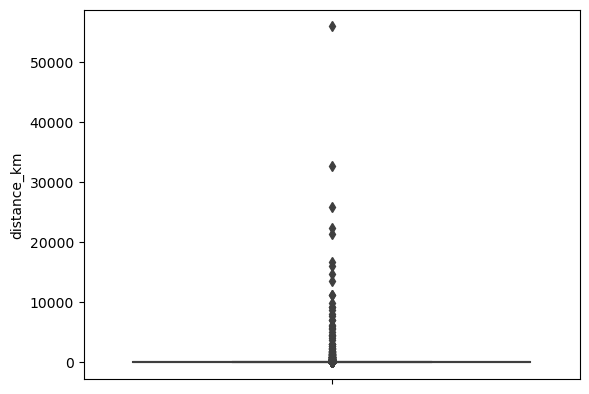

In [12]:
sns.boxplot(data=df, y="distance_km")

Мы можем увидеть что аномалии есть и выбросов много. Попробуем их отделить и проанализировать отдельно.
Рассчитаем точные границы аномалий

In [13]:
Q1 = df['distance_km'].quantile(0.25)
Q3 = df['distance_km'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Границы 'нормальных' значений: [{lower_bound:.2f}, {upper_bound:.2f}]")

Границы 'нормальных' значений: [-2.24, 6.25]


In [14]:
# Создадим отдельные датафреймы для удобного анализа:

# Аномалии
outliers = df[(df['distance_km'] < lower_bound) | (df['distance_km'] > upper_bound)]

# Нормальные значения
normal = df[(df['distance_km'] >= lower_bound) & (df['distance_km'] <= upper_bound)]

print(f"Всего поездок: {len(df)}")
print(f"Аномальных поездок: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Всего поездок: 396749
Аномальных поездок: 26495 (6.68%)


Так же посмотрим есть ли отрицательные или нулевые расстояния в наших данных:

In [15]:
# Отрицательные или нулевые расстояния (явная ошибка)
zero_or_negative = df[df['distance_km'] <= 0]
print(f"\nПоездки с distance <= 0: {len(zero_or_negative)}")


Поездки с distance <= 0: 12355


В наших данных есть аномалии. Во-первых есть поездки меньше или равные = 0 км, что явно говорит нам об ошибке. Так же у нас есть поездки длинной длинной больше 10 000 км - что явно говорит об ошибках. Уберем из нашего датафрема эти данные6 так как они могут искажать данные. Будем рассматривать поездки меньше 50 км.

### Проверим есть ли поездки, в которых дата начала поездки позже даты окончания поездки:

In [16]:
df.query('book_start_dttm > book_end_dttm').shape[0]

0

Таких данных нет

### Подготовим финальный датафрейм с которым будем в дальнейшем работать

In [17]:
final_df = df.query('distance_km > 0 and distance_km < 50')
final_df.shape

(383891, 20)

### Создадим столбец с временем поездки в минутах

In [18]:
final_df['travel_time_minute'] = (final_df.book_end_dttm - final_df.book_start_dttm).dt.total_seconds() // 60

/var/folders/hq/zg8p4rh53gjgz6dxjgr3vbfr0000gn/T/ipykernel_54504/486486064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['travel_time_minute'] = (final_df.book_end_dttm - final_df.book_start_dttm).dt.total_seconds() // 60


### Проверим есть ли поездки больше 24 часов (это либо ошибка либо аренда самоката) :

In [19]:
final_df.query('travel_time_minute / 60 > 24').shape[0]

0

Таких данных нет

## Анализ данных по моделям

###  Посмотрим распределение поездок по моделям самокатов 

In [20]:
model_data = final_df.groupby('transport_model', as_index=False)\
    .agg({
        'order_rk': 'count',                    # Количество поездок
        'distance_km': 'sum',                   # Общий пробег
        'minute_cost': 'mean',                  # Средний тариф
        'travel_time_minute': 'sum',            # Общее время аренды
        'nominal_price_rub_amt': 'sum',         # Общая выручка
        'travel_time_minute': 'mean',           # Средняя длительность поездки
        'activation_cost': 'mean',              # Средняя стоимость активации
        'hold_amount': 'mean'                   # Средний холд
    })\
    .sort_values('nominal_price_rub_amt', ascending=False)

# Переименуем наши колонки для ясности:
model_data = model_data.rename(columns={
    'order_rk': 'total_rides',
    'distance_km': 'total_distance_km',
    'nominal_price_rub_amt': 'total_revenue_rub'
})
# Создадим колонки со средней выручкой за км, доходности за час:
model_data['avg_distance_per_ride'] = model_data.total_revenue_rub / model_data.total_distance_km
model_data['revenue_per_hour'] = model_data['total_revenue_rub'] / ((model_data['travel_time_minute']\
                                                                         * model_data.total_rides) / 60)
model_data['avg_revenue_per_ride'] = model_data['total_revenue_rub'] / model_data['total_rides']
model_data['revenue_percent'] = round((model_data['total_revenue_rub'] / model_data['total_revenue_rub']\
                                        .sum()) * 100, 2)

In [21]:
model_data

,transport_model,total_rides,total_distance_km,minute_cost,travel_time_minute,total_revenue_rub,activation_cost,hold_amount,avg_distance_per_ride,revenue_per_hour,avg_revenue_per_ride,revenue_percent
11,SL,235101,610699.002320,7.627106,10.631320,31174864.03,45.328072,300.000000,51.047838,748.366167,132.602005,62.48
10,Max,67244,187492.175550,6.962107,12.647136,9028585.12,40.234816,300.000000,48.154463,636.979163,134.266033,18.09
1,E,65127,138628.149751,6.415976,11.019086,7273042.02,35.772798,300.000000,52.464395,608.079986,111.674759,14.58
13,Urban E-Bike,4338,11808.227751,7.273679,10.941678,581846.26,48.086676,300.000000,49.274647,735.505648,134.127769,1.17
6,ES400,4014,9590.044489,7.156794,14.086447,571539.24,34.333582,300.000000,59.597142,606.482755,142.386457,1.15
5,ES200,3210,6249.148885,7.286885,12.928349,462560.78,45.186916,300.000000,74.019805,668.762573,144.099931,0.93
4,ES100,2583,5475.029148,7.341529,16.217189,415951.65,34.436702,300.077429,75.972500,595.791234,161.034321,0.83
3,ES-08S,822,2032.583370,8.156545,18.236010,161697.07,38.965937,300.000000,79.552491,647.219760,196.711764,0.32
9,MK,1007,2382.775528,6.974459,15.571996,155171.28,41.380338,300.000000,65.122072,593.729788,154.092632,0.31
12,Techno,213,402.682763,7.489202,12.784038,31235.66,48.732394,300.000000,77.568903,688.262798,146.646291,0.06


Визуализируем данные:

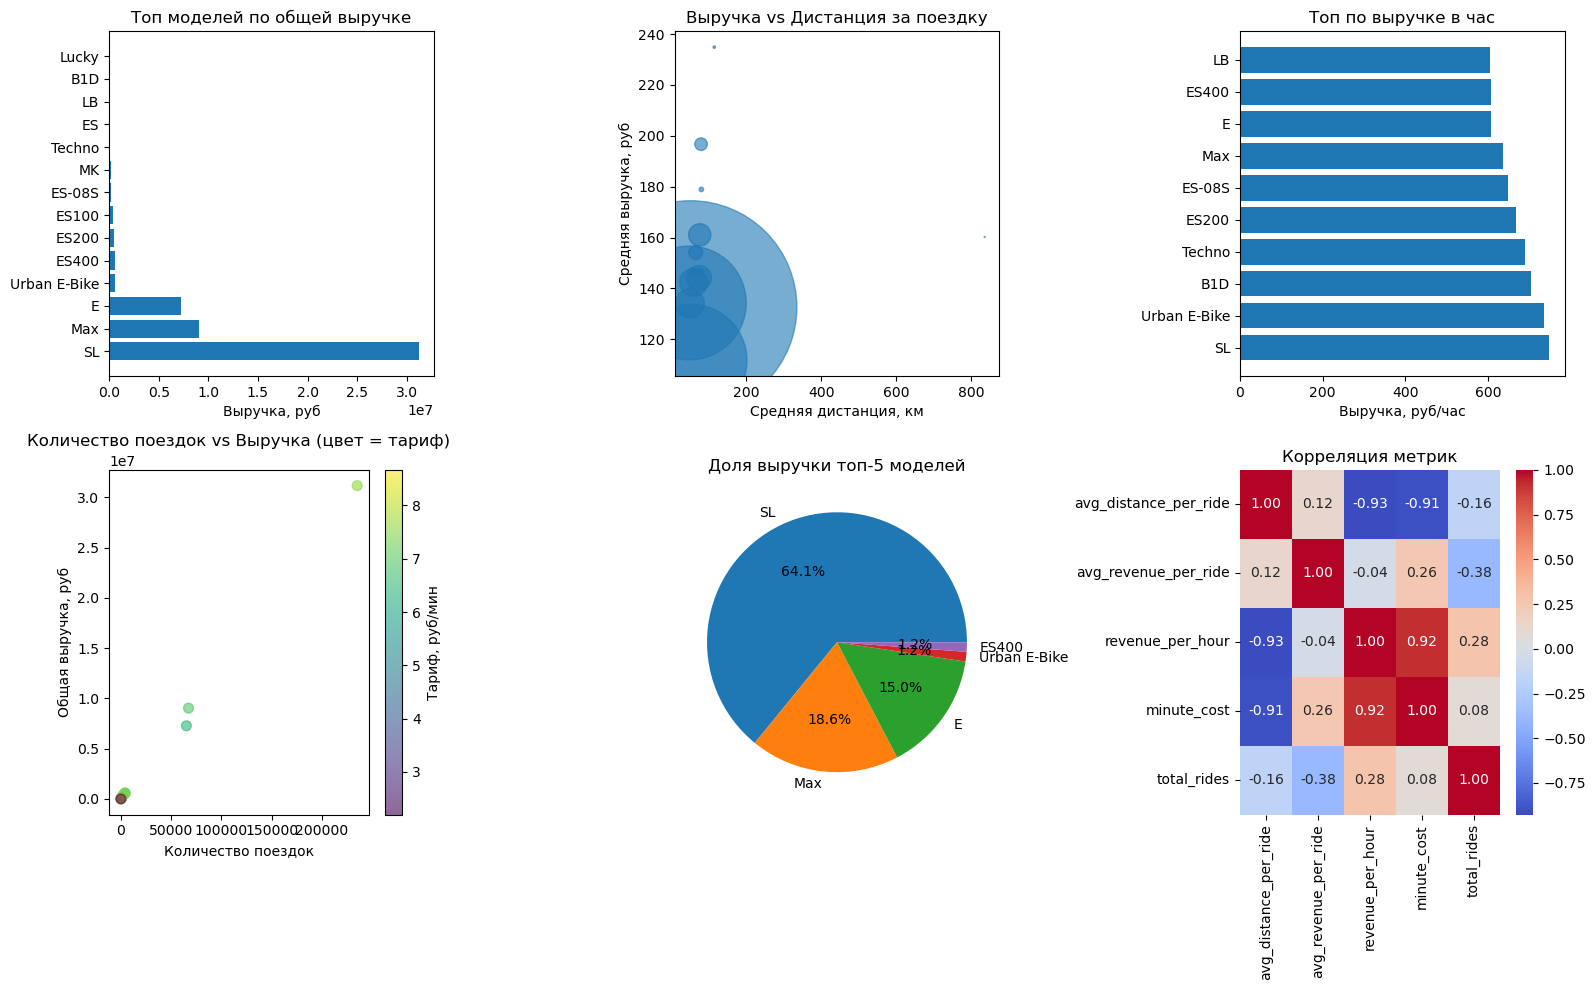

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].barh(model_data['transport_model'], model_data['total_revenue_rub'])
axes[0, 0].set_title('Топ моделей по общей выручке')
axes[0, 0].set_xlabel('Выручка, руб')


# 2. Средняя выручка за поездку
axes[0, 1].scatter(model_data['avg_distance_per_ride'], model_data['avg_revenue_per_ride'], 
                   alpha=0.6, s=model_data['total_rides']/10)
axes[0, 1].set_title('Выручка vs Дистанция за поездку')
axes[0, 1].set_xlabel('Средняя дистанция, км')
axes[0, 1].set_ylabel('Средняя выручка, руб')

# 3. Доходность (руб/час)
top_models_sorted = model_data.sort_values('revenue_per_hour', ascending=False).head(10)
axes[0, 2].barh(top_models_sorted['transport_model'], top_models_sorted['revenue_per_hour'])
axes[0, 2].set_title('Топ по выручке в час')
axes[0, 2].set_xlabel('Выручка, руб/час')

# 4. Количество поездок vs Выручка
axes[1, 0].scatter(model_data['total_rides'], model_data['total_revenue_rub'], 
                   alpha=0.6, s=50, c=model_data['minute_cost'], cmap='viridis')
axes[1, 0].set_title('Количество поездок vs Выручка (цвет = тариф)')
axes[1, 0].set_xlabel('Количество поездок')
axes[1, 0].set_ylabel('Общая выручка, руб')
plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0], label='Тариф, руб/мин')

# 5. Распределение по долям рынка
axes[1, 1].pie(model_data.head(5)['revenue_percent'], 
               labels=model_data.head(5)['transport_model'],
               autopct='%1.1f%%')
axes[1, 1].set_title('Доля выручки топ-5 моделей')

# 6. Корреляция метрик
correlation_data = model_data[['avg_distance_per_ride', 'avg_revenue_per_ride', 
                               'revenue_per_hour', 'minute_cost', 'total_rides']].corr()
sns.heatmap(correlation_data, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2])
axes[1, 2].set_title('Корреляция метрик')

plt.tight_layout()
plt.show()

## Демографический анализ

### Посмотрим на распределение пользователей по полу и возрасту:

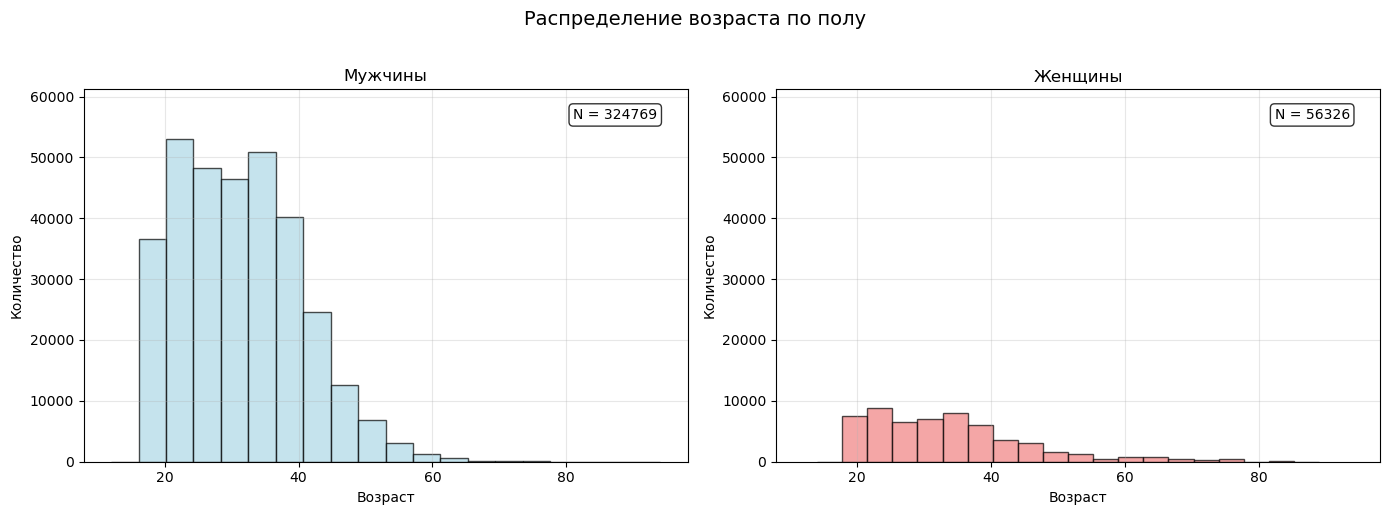

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Мужчины
male_data = final_df[final_df['gender_cd'] == 'M']['age'].dropna()
axes[0].hist(male_data, bins=20, color='lightblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Мужчины', fontsize=12)
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.95, 0.95, f'N = {len(male_data)}', 
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Женщины
female_data = final_df[final_df['gender_cd'] == 'F']['age'].dropna()
axes[1].hist(female_data, bins=20, color='lightcoral', alpha=0.7, edgecolor='black')
axes[1].set_title('Женщины', fontsize=12)
axes[1].set_xlabel('Возраст')
axes[1].set_ylabel('Количество')
axes[1].grid(True, alpha=0.3)
axes[1].text(0.95, 0.95, f'N = {len(female_data)}', 
             transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Общий заголовок
fig.suptitle('Распределение возраста по полу', fontsize=14, y=1.02)

# Синхронизируем оси для лучшего сравнения
x_min = min(axes[0].get_xlim()[0], axes[1].get_xlim()[0])
x_max = max(axes[0].get_xlim()[1], axes[1].get_xlim()[1])
y_max = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max * 1.1)

plt.tight_layout()
plt.show()

### Посмотрим на распределение по семейному положению и уровню образования

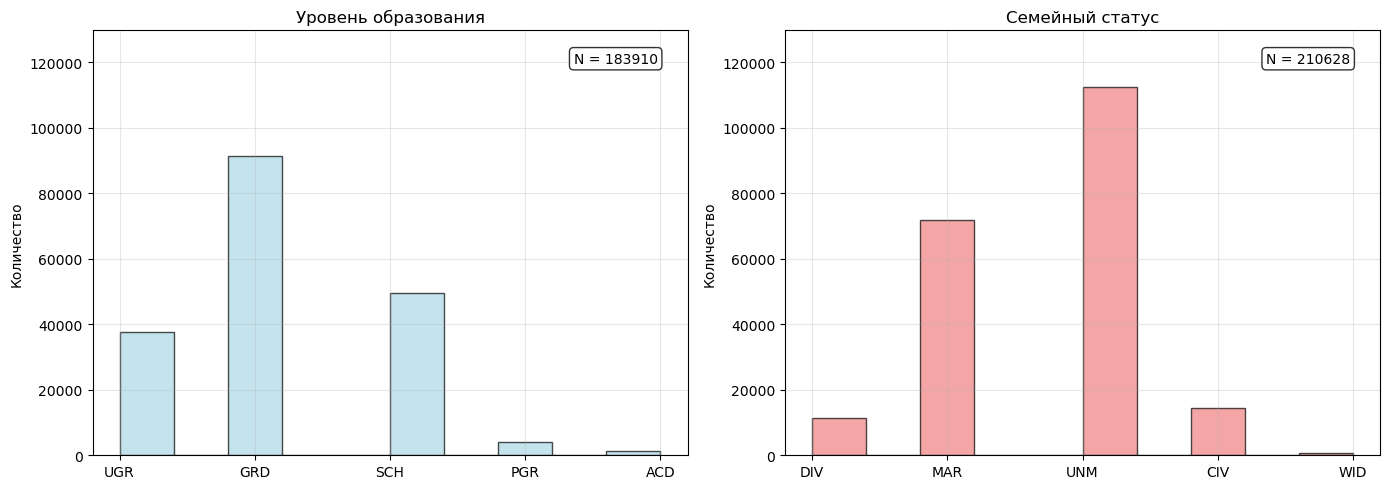

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Уровень образования
education_data = final_df['education_level_cd'].dropna()
axes[0].hist(education_data, color='lightblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Уровень образования', fontsize=12)
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.95, 0.95, f'N = {len(education_data)}', 
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# Семейный статус
marital_status_data = final_df['marital_status_cd'].dropna()
axes[1].hist(marital_status_data, color='lightcoral', alpha=0.7, edgecolor='black')
axes[1].set_title('Семейный статус', fontsize=12)
axes[1].set_ylabel('Количество')
axes[1].grid(True, alpha=0.3)
axes[1].text(0.95, 0.95, f'N = {len(marital_status_data)}', 
             transform=axes[1].transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# Синхронизируем оси для лучшего сравнения
x_min = min(axes[0].get_xlim()[0], axes[1].get_xlim()[0])
x_max = max(axes[0].get_xlim()[1], axes[1].get_xlim()[1])
y_max = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])

for ax in axes:
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max * 1.1)

plt.tight_layout()
plt.show()

## Анализ активности пользователей

Проверим есть ли у нас пользователи, которые совершали поездки больше 1 раза за все время

In [25]:
final_df.groupby('party_rk', as_index = False)\
        .order_rk.count()\
        .sort_values('order_rk', ascending = False).head(20)

,party_rk,order_rk
20797,386134592,362
48712,910211081,350
31957,636557947,324
21282,391309281,316
39841,759042976,312
9619,231464761,295
53102,1014406182,294
42212,798060910,251
59569,1164792142,240
29628,604949025,229


Мы можем видеть что есть пользователи совершавшие за весь период больше 200 поездок. Сделаем когортный анализ и посмотрим возвращаемость пользователей:

### Когортный анализ 

In [26]:
# Создадим столбец с годом и месяцем поездки
final_df['order_month'] = final_df['created_dttm'].dt.to_period('M')

/var/folders/hq/zg8p4rh53gjgz6dxjgr3vbfr0000gn/T/ipykernel_54504/2061489107.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['order_month'] = final_df['created_dttm'].dt.to_period('M')


In [28]:
# Создаём копию данных, чтобы избежать изменений в исходном DataFrame
final_df_copy = final_df.copy()

# Извлекаем день заказа
final_df_copy['order_period_day'] = final_df_copy['created_dttm'].dt.to_period('D')

# Присваиваем когорты на основе даты первого действия для каждого пользователя
final_df_copy['cohort'] = final_df_copy.groupby('party_rk')['created_dttm'].transform('min').dt.to_period('M')
final_df_copy['cohort_day'] = final_df_copy.groupby('party_rk')['created_dttm'].transform('min').dt.to_period('D')

# Рассчитываем номер периода в днях (месячные периоды, деля на 30)
final_df_copy['period_number_month'] = np.floor((final_df_copy.order_period_day - final_df_copy.cohort_day).apply(attrgetter('n')) / 30)


# Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)
df_cohort = final_df_copy.groupby(['cohort', 'period_number_month']).agg(n_customers=('party_rk', 'nunique')).reset_index()

# Создаём сводную таблицу для когортного анализа
cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')


# Рассчитываем размеры когорт (первый столбец сводной таблицы)
cohort_size = cohort_pivot.iloc[:, 0]

# Вычисляем коэффициенты удержания, деля на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)

In [29]:
retention_matrix

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0
cohort,,,,,,,
2024-04,1.0,0.500000,0.500000,0.533333,0.600000,0.333333,0.133333
2024-05,1.0,0.400995,0.338608,0.309222,0.228752,0.026673,NaN
2024-06,1.0,0.389811,0.331611,0.249569,0.081951,NaN,NaN
2024-07,1.0,0.319954,0.231382,0.080113,NaN,NaN,NaN
2024-08,1.0,0.228662,0.059801,NaN,NaN,NaN,NaN
2024-09,1.0,0.081899,NaN,NaN,NaN,NaN,NaN
2024-10,1.0,NaN,NaN,NaN,NaN,NaN,NaN


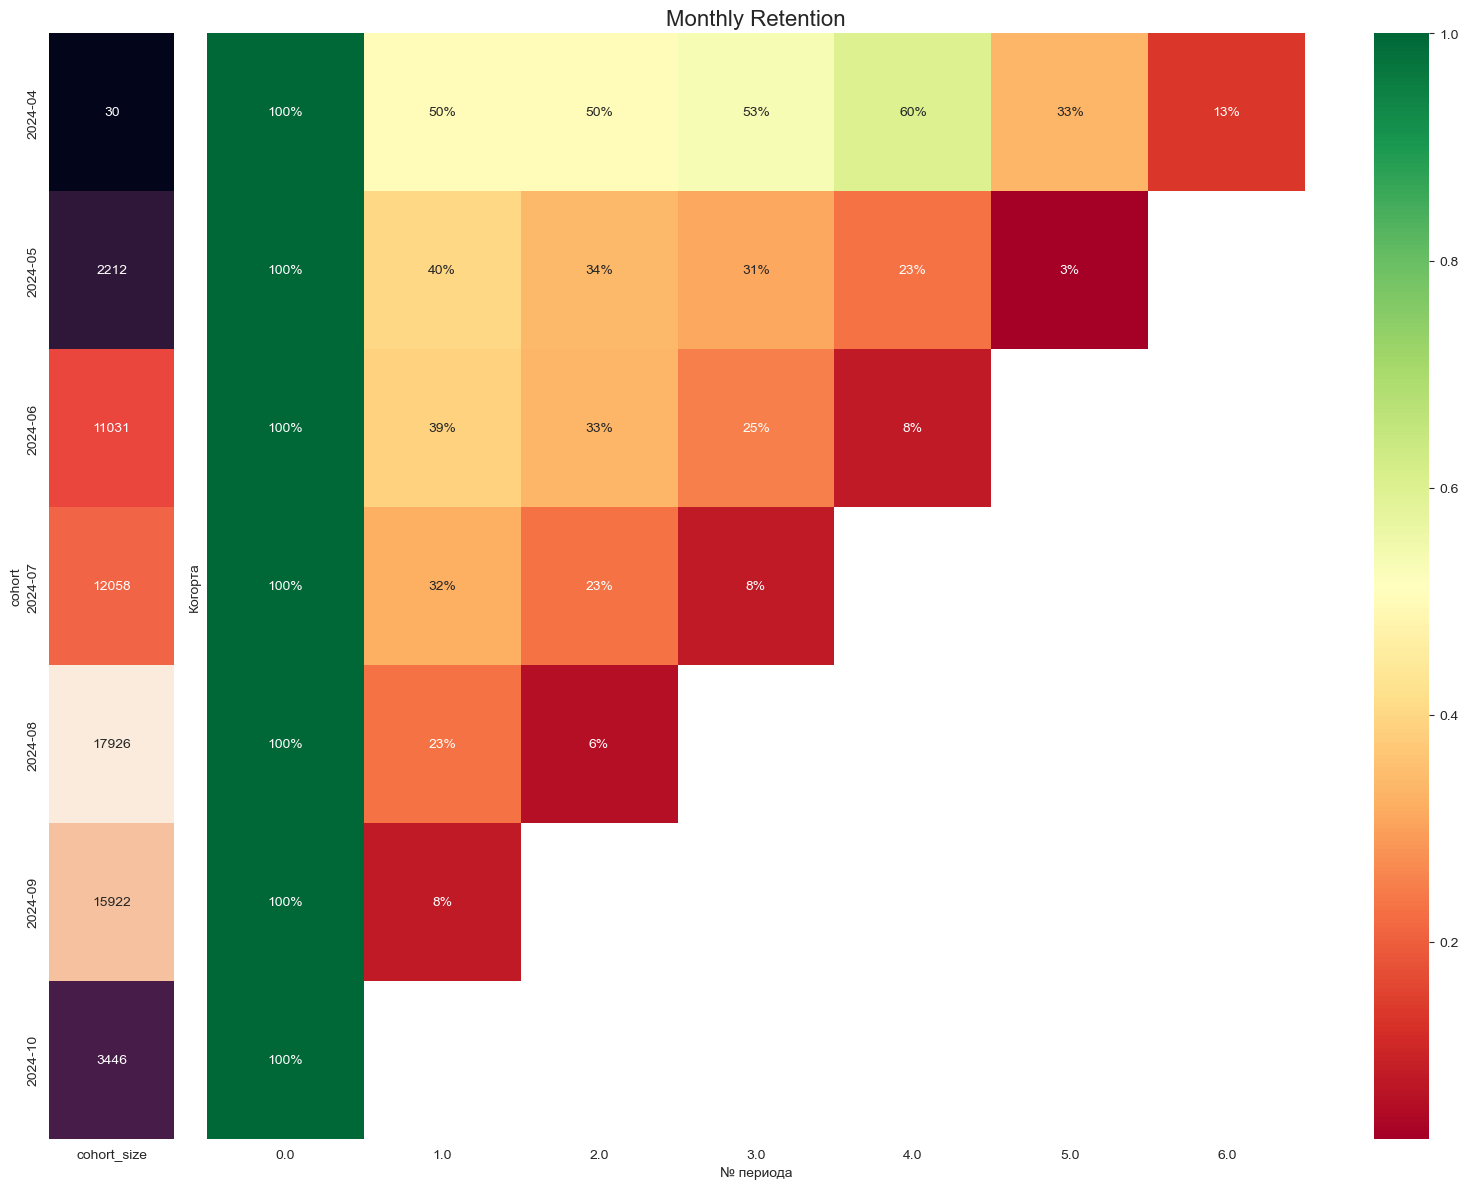

In [30]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                ax=ax[0])

    fig.tight_layout()
    plt.show()

По результатам когортного анализа можно сделать вывод что в весенне-летний период уровень retention достаточно большой. Когорты с мая по июль имеют retention в первые два месяца на уровне 30 %. Ближе к осеннему периоду данный показатель снижается что  скорее всего связано с погодными условиями.

## Анализ распределения поездок по времени

Посмотрим в какие дни и часы чаще всего совершаются поездки

In [31]:
# создадим столбцы с часом и днем недели
final_df['hour'] = final_df.book_start_dttm.dt.hour
final_df['day_of_week'] = final_df.book_start_dttm.dt.dayofweek

/var/folders/hq/zg8p4rh53gjgz6dxjgr3vbfr0000gn/T/ipykernel_54504/3247831948.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['hour'] = final_df.book_start_dttm.dt.hour
/var/folders/hq/zg8p4rh53gjgz6dxjgr3vbfr0000gn/T/ipykernel_54504/3247831948.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['day_of_week'] = final_df.book_start_dttm.dt.dayofweek


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


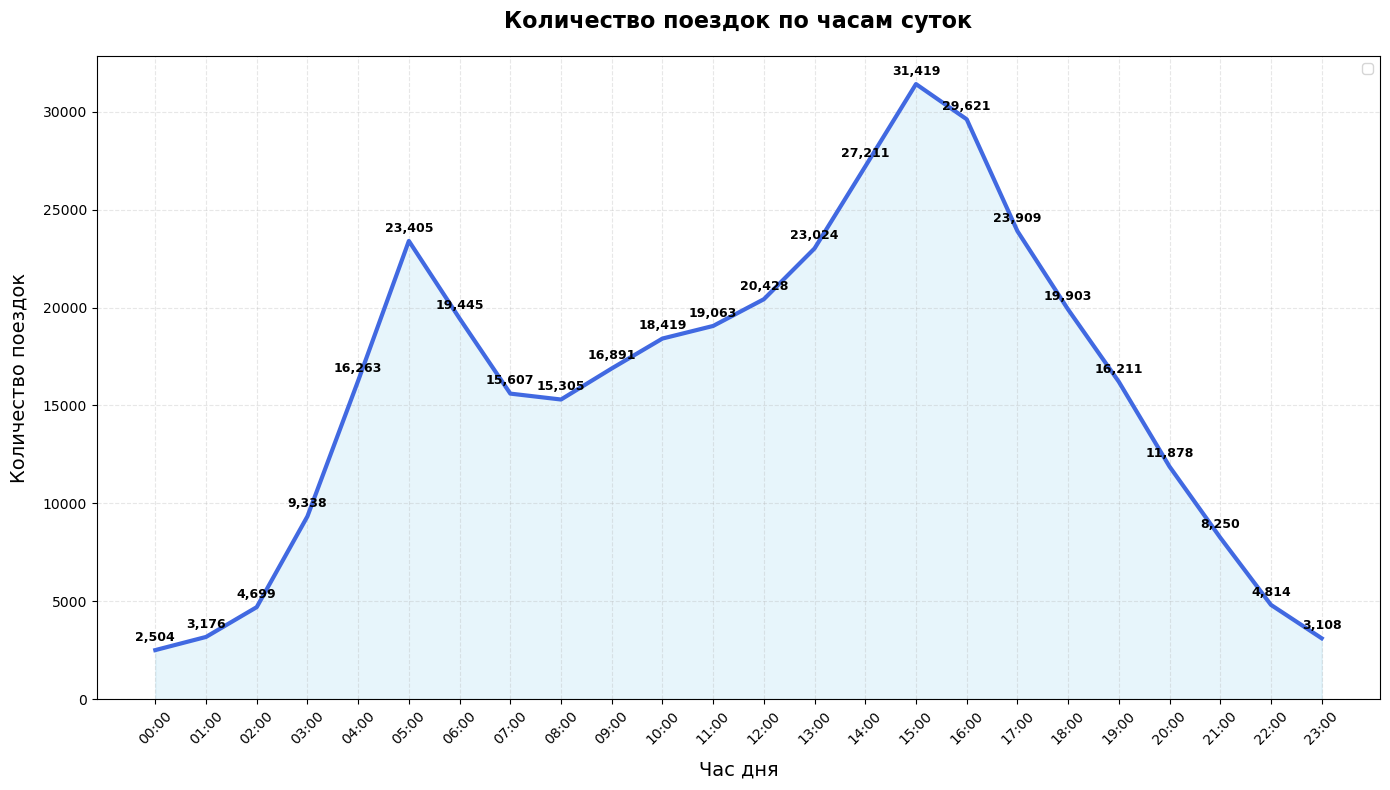

In [32]:
hourly_data = final_df.groupby('hour', as_index=False).agg({'order_rk':'count'})
hourly_data.rename(columns={'order_rk': 'order_count'}, inplace=True)

# Создаем фигуру
plt.figure(figsize=(14, 8))

# График 
ax = sns.lineplot(
    data=hourly_data, 
    x='hour', 
    y='order_count',
    linewidth=3,
    color='royalblue',
    markerfacecolor='red',
    markeredgecolor='darkred',
    markeredgewidth=2
)

# Настройки графика
plt.title('Количество поездок по часам суток', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Час дня', fontsize=14, labelpad=10)
plt.ylabel('Количество поездок', fontsize=14, labelpad=10)

# Настраиваем оси
plt.xticks(range(0, 24), [f'{h:02d}:00' for h in range(24)], rotation=45)
plt.ylim(bottom=0)  # начинаем с 0
plt.grid(True, alpha=0.3, linestyle='--')

# Добавляем подпись к точкам
for x, y in zip(hourly_data['hour'], hourly_data['order_count']):
    plt.text(x, y + (max(hourly_data['order_count']) * 0.01), 
             f'{y:,}', 
             ha='center', 
             va='bottom',
             fontsize=9,
             fontweight='bold')

# Добавляем зону заливки под кривой
plt.fill_between(hourly_data['hour'], 
                 hourly_data['order_count'], 
                 alpha=0.2, 
                 color='skyblue')



plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


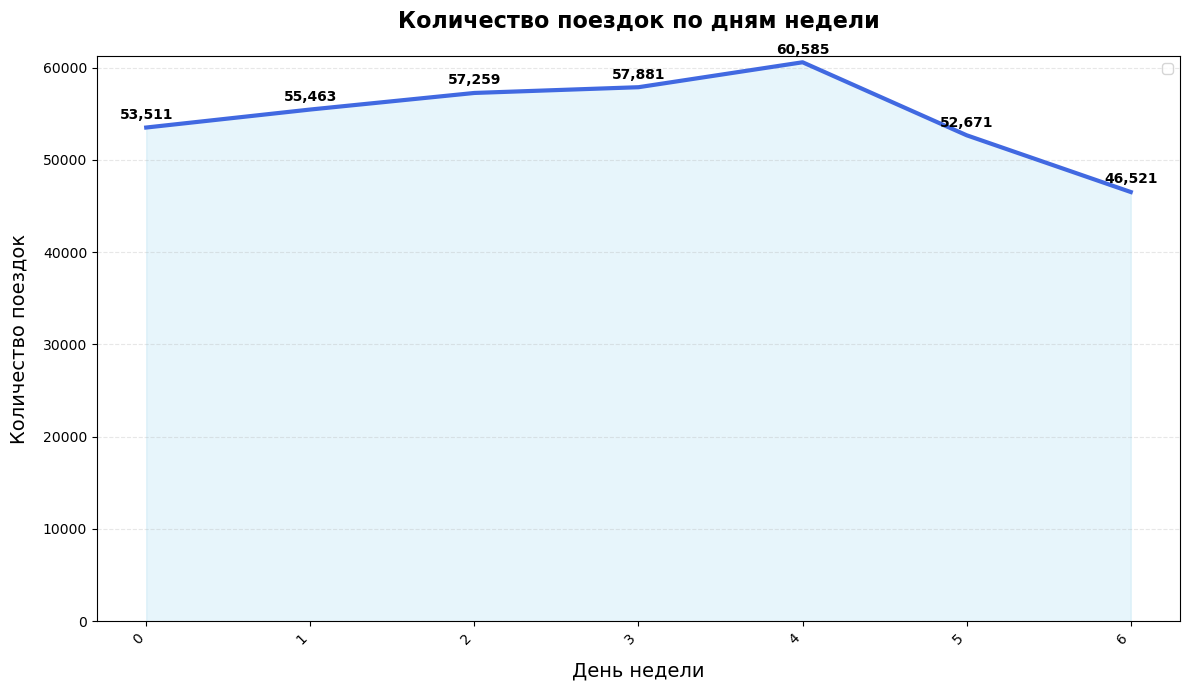

In [33]:
days_data = final_df.groupby('day_of_week', as_index=False).agg({'order_rk':'count'})
days_data.rename(columns={'order_rk': 'order_count'}, inplace=True)

# Создаем фигуру
plt.figure(figsize=(12, 7))

# График
ax = sns.lineplot(
    data=days_data, 
    x='day_of_week', 
    y='order_count',
    linewidth=3,
    color='royalblue',
    markerfacecolor='red',
    markeredgecolor='darkred',
    markeredgewidth=2
)

# Настройки графика
plt.title('Количество поездок по дням недели', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('День недели', fontsize=14, labelpad=10)  # Исправлено
plt.ylabel('Количество поездок', fontsize=14, labelpad=10)

# Настраиваем оси - теперь это дни недели, а не часы
plt.xticks(rotation=45, ha='right')  # Наклон подписей для дней
plt.ylim(bottom=0)  # начинаем с 0
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

# Добавляем подпись к точкам
for x, y in zip(range(len(days_data)), days_data['order_count']):
    day_name = days_data.iloc[x]['day_of_week']
    plt.text(x, y + (max(days_data['order_count']) * 0.01), 
             f'{y:,}', 
             ha='center', 
             va='bottom',
             fontsize=10,
             fontweight='bold')

# Добавляем зону заливки под кривой
plt.fill_between(range(len(days_data)), 
                 days_data['order_count'], 
                 alpha=0.2, 
                 color='skyblue')

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Анализ регионального распределения поездок

In [34]:
region_df = final_df.groupby('lvn_state_nm', as_index = False)\
        .agg({'order_rk':'count'})\
        .sort_values('order_rk', ascending = False)

region_df = region_df.rename(columns={
    'order_rk': 'order_count'})

region_df['percent'] = round((region_df.order_count / region_df.order_count.sum()) * 100, 2)

region_df.head(10)

,lvn_state_nm,order_count,percent
19,Г МОСКВА,88123,25.12
69,МОСКОВСКАЯ ОБЛ,38994,11.12
21,Г САНКТ-ПЕТЕРБУРГ,36204,10.32
180,СВЕРДЛОВСКАЯ ОБЛ,27967,7.97
52,КРАСНОДАРСКИЙ КРАЙ,16083,4.59
159,РЕСП ТАТАРСТАН,9205,2.62
143,РЕСП БАШКОРТОСТАН,8078,2.30
75,НИЖЕГОРОДСКАЯ ОБЛ,7428,2.12
79,НОВОСИБИРСКАЯ ОБЛ,6827,1.95
53,КРАСНОЯРСКИЙ КРАЙ,5505,1.57
